 # 4 Implementing a GPT model from scratch to generate text

## Housekeeping

In [1]:
import sys
import os
import subprocess

print("Python executable:", sys.executable)
print("Python prefix:", sys.prefix)
print("Conda environment:", os.environ.get('CONDA_DEFAULT_ENV'))
print("Conda prefix:", os.environ.get('CONDA_PREFIX'))

# Check pip location
result = subprocess.run(['which', 'pip'], capture_output=True, text=True)
print("Pip location:", result.stdout.strip())

# Check pip version
result = subprocess.run(['pip', '--version'], capture_output=True, text=True)
print("Pip version:", result.stdout.strip())

# Add environment's bin directory to PATH
env_bin = os.path.dirname(sys.executable)
current_path = os.environ['PATH']
if env_bin not in current_path:
    os.environ['PATH'] = f"{env_bin}:{current_path}"

# Verify fix
result = subprocess.run(['which', 'pip'], capture_output=True, text=True)
print("Fixed pip location:", result.stdout.strip())

Python executable: /home/sagemaker-user/.conda/envs/venv-LLMsFromScratch/bin/python3
Python prefix: /home/sagemaker-user/.conda/envs/venv-LLMsFromScratch
Conda environment: base
Conda prefix: /opt/conda
Pip location: /opt/conda/bin/pip
Pip version: pip 25.1.1 from /opt/conda/lib/python3.12/site-packages/pip (python 3.12)
Fixed pip location: /home/sagemaker-user/.conda/envs/venv-LLMsFromScratch/bin/pip


![image](../Images/Implementing_LLM_Architecture.png)

## 4.1 Coding an LLM architecture

![image](../Images/Main_Component_Highlighted.png)

In [2]:
# Specify the configuration of the small GPT-2 model via the following Python dictionary, which we will use in the code examples later:

GPT_CONFIG_124M = {
    "vocab_size" : 50257,
    "context_length" : 1024, # denotes the maximum number of input tokens the model can handle via the positional embeddings 
    "emb_dim" : 768,
    "n_heads" : 12, # indicates the count of attention heads in the multi-head attention mechanism
    "n_layers" : 12, # Number of transformers blocks/layers
    "drop_rate" : 0.1,
    "qkv_bias" : False
}
    

![GPT Architecture](../Images/GPT_Architecture.png)

## Listing 4.1 A placeholder GPT model architecture class

In [3]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"]) # Using Embedding Function of Pytorch
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"]) # This will be part of embeddings

        self.drop_out = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential( *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])] )

        self.final_norm = DummyLayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear( cfg["emb_dim"], cfg["vocab_size"], bias = False )


    def forward(self, in_idx):

        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb( torch.arange(seq_len, device = in_idx.device) )

        x = tok_embeds + pos_embeds

        x = self.drop_out(x)

        x = self.trf_blocks(x)

        x = self.final_norm(x)

        logits = self.out_head(x)

        return logits


class DummyTransformerBlock(nn.Module): #3 A simple placeholder class that will be replaced by a real TransformerBlock later 
    def __init__(self, cfg):
        super().__init__()


    def forward(self, x): #4 This block does nothing and just returns its input. 

        return x


class DummyLayerNorm(nn.Module): #5 A simple placeholder class that will be replaced by a real LayerNorm later 
    def __init__(self, normalized_shape, eps = 1e-5): #6 The parameters here are just to mimic the LayerNorm interface. 
        super().__init__()


    def forward(self, x):

        return x
        

![Data Flow in GPT Architecture](../Images/Data_flow_in_gpt_arch.png)

## Tokenizing

In [4]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every efforts move you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 4040, 1445,  345],
        [6109, 1110, 6622,  257]])


In [5]:
torch.manual_seed(35)

model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 1.3364,  0.8170, -0.2211,  ...,  0.1361, -0.7352, -0.2771],
         [-0.2796,  0.3339,  0.0578,  ...,  0.4695, -0.4146,  0.6163],
         [ 0.6552, -0.8949,  0.2170,  ..., -0.1467,  1.4401, -0.0812],
         [-1.2330,  0.5162,  0.9219,  ..., -1.1361,  0.2683, -0.3193]],

        [[ 1.0889,  0.6308, -0.2090,  ..., -0.3449, -0.3445, -0.4082],
         [ 0.6271,  2.0863,  1.3722,  ..., -1.6971,  0.1060, -1.1506],
         [-0.4402, -0.5588,  0.4715,  ..., -0.7018,  1.3462, -0.1949],
         [ 0.8621, -0.4782,  1.0876,  ..., -0.8677, -0.8146, -0.4099]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.2 Normalizing activations with layer normalization

![Layer Normalization](../Images/Layer_Normalization.png)

In [6]:
torch.manual_seed(35)

batch_example = torch.rand(2,5)
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)

In [7]:
print(batch_example)
print(batch_example.shape)
print(out)

tensor([[0.2621, 0.1475, 0.9375, 0.1900, 0.2607],
        [0.0034, 0.0207, 0.2002, 0.2121, 0.1974]])
torch.Size([2, 5])
tensor([[0.3301, 0.2510, 0.0496, 0.1718, 0.2926, 0.5459],
        [0.4259, 0.3570, 0.0000, 0.1153, 0.3836, 0.2849]],
       grad_fn=<ReluBackward0>)


In [8]:
print(torch.sum(out[1]))
print(torch.sum(batch_example[1]))

tensor(1.5667, grad_fn=<SumBackward0>)
tensor(0.6337)


In [9]:
# Here we are calculating mean and variance of matrix along the row

mean = out.mean(dim = -1, keepdim = True)
var = out.var(dim = -1, keepdim = True)

print(mean)
print(var)

tensor([[0.2735],
        [0.2611]], grad_fn=<MeanBackward1>)
tensor([[0.0278],
        [0.0283]], grad_fn=<VarBackward0>)


In [10]:
# Here we are using mean and variance calculated earlier to normalize the values
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim = -1, keepdim = True)
var = out_norm.var(dim= -1, keepdim = True)

print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.3398, -0.1351, -1.3442, -0.6104,  0.1147,  1.6352],
        [ 0.9798,  0.5704, -1.5530, -0.8672,  0.7285,  0.1414]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[-4.9671e-08],
        [-5.9605e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [11]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    -0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## Listing 4.2 A layer normalization class

In [12]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        self.eps = 1e-5

        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim = -1, keepdim = True)
        var = x.var(dim = -1, keepdim = True)

        norm_x = (x-mean)/torch.sqrt(var+self.eps)

        return self.scale*norm_x + self.shift

In [13]:
ln = LayerNorm(emb_dim = 6)
out_ln = ln(out)
mean = out_ln.mean(dim=-1, keepdim = True)
var = out_ln.var(dim = -1, unbiased = False, keepdim = True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    -0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.8330],
        [0.8330]], grad_fn=<VarBackward0>)


### Layer normalization vs. batch normalization

```If you are familiar with batch normalization, a common and traditional normalization method for neural networks, you may wonder how it compares to layer normalization. Unlike batch normalization, which normalizes across the batch dimension, layer normalization normalizes across the feature dimension. LLMs often require significant computational resources, and the available hardware or the specific use case can dictate the batch size during training or inference. Since layer normalization normalizes each input independently of the batch size, it offers more flexibility and stability in these scenarios. This is particularly beneficial for distributed training or when deploying models in environments where resources are constrained.```


## 4.3 Implementing a feed forward network with GELU activations

### Listing 4.3 An implementation of the GELU activation function

In [14]:
class GELU(nn.Module): # blueprint + PyTorch ki powers
    def __init__(self): # setup tyaar karna jab bhi iss class ka koi naya object banayega
        super().__init__() # phele nn.Module ka setup tyaar karo 

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh( torch.sqrt( torch.tensor(2.0/torch.pi) ) * ( x + 0.044715 * torch.pow(x,3)) ))

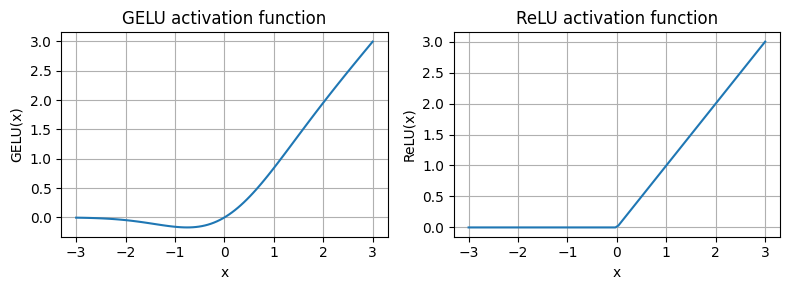

In [15]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)

y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8,3))

for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

### Listing 4.4 A feed forward neural network module

In [16]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(  nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), # Pehle room banao — zyada jagah mein sochna aasaan hai"
                                      nn.GELU(),                                     # Important cheezein rakho, bekar cheezein hatao
                                      nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), # Jo important tha woh compress karke wapas laao
                                   )

    def forward(self,x):
        return self.layers(x)

In [17]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


## 4.4 Adding shortcut connections

### Shortcut kyun zaroori hai?

  Bina shortcut ke deep networks mein ek problem aati hai:

  <pre>
  Layer 1 → Layer 2 → Layer 3 → Layer 4 → Layer 5
      ↓
  Jab error wapas jaata hai (backpropagation),
  tab tak itna chhota ho jaata hai ki
  Layer 1 kuch seekh hi nahi paata
  </pre>

  Isko kehte hain → **"Vanishing Gradient Problem"**

  Shortcut se:
  - Error seedha Layer 1 tak pahunch jaata hai
  - Kyunki shortcut ek direct raasta deta hai
  - Isliye training bahut better hoti hai

  ---

  ### Poori class ek baar mein:

  <pre>
  ExampleDeepNeuralNetwork banao
          ↓
  5 layers banao (Linear + GELU each)
          ↓
  Data aaya → har layer se guzaaro
          ↓
  Agar shortcut on hai aur size match karta hai:
      output = layer ka kaam + seedha input bhi add karo
  Warna:
      output = sirf layer ka kaam
          ↓
  Final output return karo
  </pre>

In [18]:
class ExampleDeepNeuralNetwork(nn.Module): # Naya blueprint bana raha hoon — "Deep Neural Network" -   nn.Module se neev le raha hoon (PyTorch ki saari powers milein)
    def __init__(self, layer_size, use_shortcut):   # layer_sizes  →  har layer kitni badi hogi — ek list jaise [3, 4, 5, 6, 7, 8]  ← 6 numbers, 5 layers,   use_shortcut →  True ya False kya shortcut connections use karni hain?
        
        """
          Pehle nn.Module ka apna setup karo
          Phir apna kaam karo
          Zaruri hai — bina iske PyTorch kaam nahi karega
        """
        super().__init__()

        self.use_shortcut = use_shortcut # Bahar se jo True/False aaya, use yaad rakhlo Aage forward() mein kaam aayega

        self.layers = nn.ModuleList( [  # PyTorch ko bata rage hai ki yeh mere layers hain, inhe sambhalo 
                        nn.Sequential( nn.Linear(layer_size[0], layer_size[1]), GELU()),
                        nn.Sequential( nn.Linear(layer_size[1], layer_size[2]), GELU()),
                        nn.Sequential( nn.Linear(layer_size[2], layer_size[3]), GELU()),
                        nn.Sequential( nn.Linear(layer_size[3], layer_size[4]), GELU()),
                        nn.Sequential( nn.Linear(layer_size[4], layer_size[5]), GELU()),
                        ] )

    def forward(self, x): # asli kaam yahan hota hai

        for layer in self.layers: # Har layer pe ek ek karke jao
            layer_output = layer(x) # iss layer se data guzaaro, output lo

            """
              Do conditions ek saath check ho rahi hain:

              Condition 1 — self.use_shortcut
              Kya shortcut on hai? (True/False)
            
              Condition 2 — x.shape == layer_output.shape
              Kya input aur output ka size same hai?
              Sirf tab shortcut possible hai jab sizes match karein
            
              3 → 4   shapes alag hain  ✗ shortcut nahi ho sakta
              4 → 4   shapes same hain  ✓ shortcut ho sakta hai
            """
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output

            """
              Socho tum 5 manzil chadh rahe ho

              Normal:   Har manzil pe pehle wali cheez bhool jao, sirf nayi cheez yaad rakho
              
              Shortcut: Har manzil pe nayi cheez seekho + pehle wali cheez bhi saath rakho
                        → Neeche ki information upar tak pahunchti rehti hai
            """

        return x

In [19]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(35)

model_without_shortcut = ExampleDeepNeuralNetwork( layer_sizes, use_shortcut = False)
model_without_shortcut

ExampleDeepNeuralNetwork(
  (layers): ModuleList(
    (0-3): 4 x Sequential(
      (0): Linear(in_features=3, out_features=3, bias=True)
      (1): GELU()
    )
    (4): Sequential(
      (0): Linear(in_features=3, out_features=1, bias=True)
      (1): GELU()
    )
  )
)

In [20]:
model_without_shortcut.state_dict()

OrderedDict([('layers.0.0.weight',
              tensor([[-0.2747, -0.4070,  0.5052],
                      [-0.3580, -0.2763, -0.5735],
                      [-0.5535, -0.3462, -0.3324]])),
             ('layers.0.0.bias', tensor([-0.3494,  0.0055, -0.2365])),
             ('layers.1.0.weight',
              tensor([[-0.1525,  0.3961,  0.4130],
                      [-0.2745,  0.1579, -0.1243],
                      [ 0.3655,  0.2182,  0.5308]])),
             ('layers.1.0.bias', tensor([0.4656, 0.2602, 0.5424])),
             ('layers.2.0.weight',
              tensor([[ 0.1445,  0.3794,  0.2735],
                      [-0.0722,  0.2669, -0.0124],
                      [-0.3461, -0.5084,  0.0989]])),
             ('layers.2.0.bias', tensor([ 0.3702, -0.4462,  0.1979])),
             ('layers.3.0.weight',
              tensor([[-0.5525,  0.4655,  0.4975],
                      [ 0.3730,  0.4196,  0.3628],
                      [-0.5285,  0.1022,  0.4967]])),
             ('layers.3.0.

In [21]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [22]:
# Not using shortcut
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.0019088867120444775
layers.1.0.weight has gradient mean of 0.002164652803912759
layers.2.0.weight has gradient mean of 0.007044170517474413
layers.3.0.weight has gradient mean of 0.010286778211593628
layers.4.0.weight has gradient mean of 0.05396035313606262


In [23]:
# using shortcut
torch.manual_seed(35)

model_with_shortcut = ExampleDeepNeuralNetwork( layer_sizes, use_shortcut = True)

print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.005401268135756254
layers.1.0.weight has gradient mean of 0.007059985771775246
layers.2.0.weight has gradient mean of 0.0021025515161454678
layers.3.0.weight has gradient mean of 0.004320079926401377
layers.4.0.weight has gradient mean of 0.04245075583457947


## 4.5 Connecting attention and linear layers in a transformer block

### Listing 4.6 The transformer block component of GPT

### Coding Multihead Attention Again

  ---
  Concept samjhtai hai — Multi Head Attention kya hai?
  
  Socho tum ek sentence padh rahe ho:
  "Rahul ne ball maari aur woh door gayi"

  "woh" ka matlab kya hai? Ball? Ya Rahul?

  Tumhara dimaag automatically "woh" → "ball" connect karta hai.

  Attention yahi kaam karta hai — har word ka doosre words se connection dhundho

  Multi-Head matlab:
  Ek aadmi poori cheez dekhe        → Single Head
  Alag alag experts alag alag cheez dekhe → Multi Head

  Head 1 → Grammar connections dhundhe
  
  Head 2 → Meaning connections dhundhe
  
  Head 3 → Subject-Object connections dhundhe
  ...
  Sab milake ek final answer do

  ---

In [24]:
class MultiHeadAttention(nn.Module):
    """
    d_in = input ka size (har token ke kitne numbers hain) - matlab kitne dimensions mai represent ho raha hai - isko apun log shape kai sath confuse nahi karengai
    d_out = output ka kya size hoga
    context_length = ktine tokens ek baar mai dekh saktai hai( matlab total input tokens kitnai hongai)
    dropout = overfitting roknai kai liye ( khuch connections ko randomly off kardengai)
    num_heads = kitne expers parallel mai kaam karengai ( yaha yeh confusion hai ki yeh sab ek hi transformer block mai hongai yaa har ek head apnai khud kai transformer block mai hoga
    qkv_bias = Linear layers jo hum use kar rahe hai usmai bias variable use karna hai ki nahi 
    """
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias):
        super().__init__()

        assert( d_out % num_heads == 0 ),  "d_out must be divisible by num_heads" # Kaam barabar baantna hai — toh total kaam, heads se bilkul divide hona chahiye 

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # 

        """
          Teen Linear layers — W_query, W_key, W_value:
          self.W_query = nn.Linear(d_in, d_out)
          self.W_key   = nn.Linear(d_in, d_out)
          self.W_value = nn.Linear(d_in, d_out)
        
          Library analogy:
          Query  →  "Mujhe kya chahiye?"     (question)
          Key    →  "Mere paas kya hai?"     (label/index)
          Value  →  "Mera actual content"    (answer)
        
          Jaise library mein:
          Query  = tumhari search query
          Key    = har book ka title
          Value  = book ka actual content
        
          Jis book ka title (Key) tumhari query se match kare,
          usi book ka content (Value) lo
        """

        self.W_query = nn.Linear(d_in, d_out)
        self.W_key = nn.Linear(d_in, d_out)
        self.W_value = nn.Linear(d_in, d_out)

        """
          Saare heads ka output ek saath aata hai
          out_proj unhe milake ek final output banata hai
        
          4 experts ne alag alag kaam kiya
          out_proj ne unki report milake ek final report banayi
        """
        self.out_proj = nn.Linear(d_out, d_out)


        self.dropout = nn.Dropout(dropout)


        """
          Do cheezein hain yahan:
        
          torch.triu(..., diagonal=1) — upper triangular matrix:
          context_length = 4 ke liye:
        
          [[0, 1, 1, 1],
           [0, 0, 1, 1],
           [0, 0, 0, 1],
           [0, 0, 0, 0]]
        
          1 matlab → "yeh future token hai, mat dekho"
          0 matlab → "yeh dekh sakte ho"
          "Token 1 sirf Token 1 dekhe, Token 2 sirf 1-2 dekhe, future mat dekhe"
        
          register_buffer — mask ko model ke saath save karo, lekin yeh trainable parameter nahi hai:
          # Normal parameter    → training mein badalta hai (weights)
          # register_buffer     → fix rehta hai, lekin model ke saath GPU pe jaata hai
        """
        self.register_buffer("mask", torch.triu( torch.ones(context_length, context_length), diagonal = 1))



    def forward(self, x):
        b, num_tokens, d_in = x.shape
        """
          b, num_tokens, d_in = x.shape
          x ka shape [2, 4, 8] hai toh:
          b          = 2  (2 sentences ek saath — batch)
          num_tokens = 4  (har sentence mein 4 tokens)
          d_in       = 8  (har token ke 8 numbers)
        """
        
        # Teeno Linear layers se guzaar kai  — teen alag perspectives mil rahe hai
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # 8 numbers ko 4 experts mein baant do — har expert ke paas 2 numbers
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Pehle heads ko aage laao — taaki har head apne saare tokens ek saath dekhe
        # Pehle:  [batch, tokens, heads, dim]  →  har token ke andar heads hain
        # Baad:   [batch, heads, tokens, dim]  →  har head ke andar tokens hain ✓
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        # Query × Key  →  "Kitna match hai?"
        attn_scores = queries @ keys.transpose(2,3)

        # -infinity isliye kyunki baad mein softmax aayega — softmax(-inf) = 0 ho jaata hai
        mask_bool = self.mask.bool ()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim = -1)

        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1,2)

        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)

        context_vec = self.out_proj(context_vec)

        return context_vec

## Listing 4.6 The transformer block component of GPT

In [25]:
class TransformerBlock(nn.Module):

    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
                        d_in = cfg["emb_dim"],
                        d_out = cfg["emb_dim"],
                        context_length = cfg["context_length"],
                        num_heads = cfg["n_heads"],
                        dropout = cfg["drop_rate"],
                        qkv_bias = cfg["qkv_bias"]
                    )

        self.ff = FeedForward(cfg)

        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])

        self.dropout_shortcut = nn.Dropout(cfg["drop_rate"])
        print(cfg)
        print(type(cfg["context_length"]))


    def forward(self, x):
        shortcut = x

        x = self.norm1(x)
        x = self.att(x)
        x = self.dropout_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.dropout_shortcut(x)
        x = x + shortcut

        return x

In [26]:
torch.manual_seed(35)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
<class 'int'>
Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [27]:
print(type(GPT_CONFIG_124M["emb_dim"]))

<class 'int'>


## 4.6 Coding the GPT model

In [28]:
# import torch
# import torch.nn as nn

# class DummyGPTModel(nn.Module):
#     def __init__(self, cfg):
#         super().__init__()

#         self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"]) # Using Embedding Function of Pytorch
#         self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"]) # This will be part of embeddings

#         self.drop_out = nn.Dropout(cfg["drop_rate"])

#         self.trf_blocks = nn.Sequential( *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])] )

#         self.final_norm = DummyLayerNorm(cfg["emb_dim"])

#         self.out_head = nn.Linear( cfg["emb_dim"], cfg["vocab_size"], bias = False )


#     def forward(self, in_idx):

#         batch_size, seq_len = in_idx.shape

#         tok_embeds = self.tok_emb(in_idx)
#         pos_embeds = self.pos_emb( torch.arange(seq_len, device = in_idx.device) )

#         x = tok_embeds + pos_embeds

#         x = self.drop_out(x)

#         x = self.trf_blocks(x)

#         x = self.final_norm(x)

#         logits = self.out_head(x)

#         return logits


# class TransformerBlock(nn.Module): #3 A simple placeholder class that will be replaced by a real TransformerBlock later 
#     def __init__(self, cfg):
#         super().__init__()


#     def forward(self, x): #4 This block does nothing and just returns its input. 

#         return x


# class LayerNorm(nn.Module): #5 A simple placeholder class that will be replaced by a real LayerNorm later 
#     def __init__(self, normalized_shape, eps = 1e-5): #6 The parameters here are just to mimic the LayerNorm interface. 
#         super().__init__()


#     def forward(self, x):

#         return x
        

### Listing 4.7 The GPT model architecture implementation

In [29]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential( *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias = False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb( torch.arange(seq_len, device = in_idx.device) )

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)

        logits = self.out_head(x)

        return logits

In [30]:
torch.manual_seed(35)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
<class 'int'>
{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
<class 'int'>
{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
<class 'int'>
{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
<class 'int'>
{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
<class 'int'>
{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
<class 'int'>
{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': False}
<class

In [31]:
model

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query):

In [32]:
model.state_dict()

OrderedDict([('tok_emb.weight',
              tensor([[ 0.1838,  0.1832, -2.3538,  ..., -1.9861, -0.4840,  0.5587],
                      [ 1.1507, -0.3149,  1.6193,  ...,  0.5302, -0.2202, -0.1446],
                      [-1.0750, -0.7655,  1.2927,  ..., -2.2761,  0.1214,  1.7711],
                      ...,
                      [ 1.2466, -1.3795, -0.3455,  ...,  2.2291,  0.2667,  0.6970],
                      [ 2.9949, -0.4546,  0.2981,  ..., -1.2399, -0.6345, -1.1012],
                      [-0.9599, -1.2409,  1.1246,  ...,  0.0996, -1.3305, -0.2398]])),
             ('pos_emb.weight',
              tensor([[ 1.1672, -2.3490,  0.3394,  ..., -0.9451, -1.6762,  1.0516],
                      [-1.1187, -0.1762, -1.6063,  ..., -2.3172,  0.1707, -0.9644],
                      [-0.5566, -0.2787, -0.5336,  ..., -0.5689,  1.4578,  2.3338],
                      ...,
                      [-0.3461, -1.2468, -0.9071,  ...,  0.0890, -0.7317,  0.7836],
                      [ 1.1626,  0.8916

In [33]:
model.parameters()

<generator object Module.parameters at 0x7faf5e438200>

In [34]:
total_params = sum(p.numel() for p in model.parameters())
total_params

163037184

In [36]:
print("tok_emb:    ", model.tok_emb.weight.numel())
print("pos_emb:    ", model.pos_emb.weight.numel())
print("trf_blocks: ", sum(p.numel() for p in model.trf_blocks.parameters()))
print("final_norm: ", sum(p.numel() for p in model.final_norm.parameters()))
print("out_head:   ", sum(p.numel() for p in model.out_head.parameters()))

tok_emb:     38597376
pos_emb:     786432
trf_blocks:  85054464
final_norm:  1536
out_head:    38597376


In [37]:
model.tok_emb.weight.shape

torch.Size([50257, 768])

In [39]:
model.out_head.weight.shape

torch.Size([50257, 768])

In [40]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
      f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,439,808


In [ ]:
wight